In [1]:
# Load Data for Analysis
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import traceback

In [2]:
import os
import sys
from pathlib import Path

# In a Jupyter Notebook, __file__ is not defined.
# Use os.getcwd() or Path.cwd() to get the current working directory,
# which is often the project root when running notebooks.
try:
    # This will work if running as a .py script
    current_file_path = Path(__file__).resolve()
    project_dir = current_file_path.parent
except NameError:
    # This will work in a Jupyter Notebook
    print("Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.")
    project_dir = Path.cwd() # Or Path('.').resolve()

print(f"Project directory: {project_dir}")

src_dir = project_dir / 'src'
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))
print(f"src directory {src_dir} added to sys.path if not already there.")

Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.
Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
src directory C:\Users\hidbe\PycharmProjects\MOGRN\src added to sys.path if not already there.


In [3]:
# Set project directories
project_dir = os.path.dirname(os.path.abspath('__file__'))
output_dir = os.path.join(project_dir, 'opsin_output')
cache_dir = os.path.join(output_dir, 'cache')
grn_tables_dir = os.path.join(project_dir, 'opsin_grn_tables')

print(f"Project directory: {project_dir}")
print(f"Output directory: {output_dir}")
print(f"Cache directory: {cache_dir}")
print(f"GRN tables directory: {grn_tables_dir}")

# Initialize data dictionary
data = {}  # This will hold all our analysis data

Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
Output directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output
Cache directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache
GRN tables directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_grn_tables


In [4]:
# Function to load cached data
def load_cached_data(cache_path, description="data"):
    """Load cached data from pickle file"""
    try:
        if os.path.exists(cache_path):
            print(f"Loading {description} from cache: {cache_path}")
            with open(cache_path, 'rb') as f:
                result = pickle.load(f)
                print(f"Successfully loaded {description}")
                return result
        else:
            print(f"Cache file not found: {cache_path}")
            return None
    except Exception as e:
        print(f"Error loading {description} from cache: {e}")
        traceback.print_exc()
        return None

# Load GRN tables data if available
def load_grn_tables_data():
    grn_tables_pkl = os.path.join(grn_tables_dir, 'grn_tables_data.pkl')
    if os.path.exists(grn_tables_pkl):
        try:
            with open(grn_tables_pkl, 'rb') as f:
                grn_data = pickle.load(f)
                print(f"Successfully loaded GRN tables data")
                return grn_data
        except Exception as e:
            print(f"Error loading GRN tables data: {e}")
            traceback.print_exc()
    else:
        print(f"GRN tables data file not found: {grn_tables_pkl}")
    return None

# Load main workflow data
chain_id = 'A'

# Try to load all cached data from the workflow
cache_files = {
    "raw_structures": (f"raw_structures_{chain_id}.pkl", "raw structures"),
    "processed_structures": (f"processed_structures_{chain_id}.pkl", "processed structures"),
    "structure_errors": (f"structure_errors_{chain_id}.pkl", "structure errors"),
    "helix_annotations": (f"helix_annotations_{chain_id}.pkl", "helix annotations"),
    "structure_comparison": (f"structure_comparison_{chain_id}.pkl", "structure comparison"),
    "grn_assignment": (f"grn_assignment_{chain_id}.pkl", "GRN assignment")
}

for data_type, (file_name, description) in cache_files.items():
    cache_path = os.path.join(cache_dir, file_name)
    component_data = load_cached_data(cache_path, description)
    if component_data:
        # If the component data is a dictionary, update the main data dictionary
        if isinstance(component_data, dict):
            data.update(component_data)
        # Otherwise store it directly
        else:
            data[data_type] = component_data

# Additionally, load the GRN tables data
grn_data = load_grn_tables_data()
if grn_data:
    data.update(grn_data)
    
# Print confirmation of data loading
print(f"\nLoaded data with {len(data.keys())} top-level keys")
if 'processed_structures' in data:
    print(f"Found {len(data['processed_structures'])} processed structures")

Cache file not found: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\raw_structures_A.pkl
Loading processed structures from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\processed_structures_A.pkl
Successfully loaded processed structures
Loading structure errors from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\structure_errors_A.pkl
Successfully loaded structure errors
Loading helix annotations from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\helix_annotations_A.pkl
Successfully loaded helix annotations
Loading structure comparison from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\structure_comparison_A.pkl
Successfully loaded structure comparison
Loading GRN assignment from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\grn_assignment_A.pkl
Successfully loaded GRN assignment
GRN tables data file not found: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_grn_tables\grn_tables_data.pkl

Loaded d

In [5]:
# Check available components and datasets in the loaded data
def print_data_summary(data):
    """Print summary of loaded data"""
    print("\n=== DATA SUMMARY ===")
    
    # Print top-level keys
    print("\nTop-level components:")
    for key in sorted(data.keys()):
        print(f"- {key}")
    
    # Print dataset information if available
    if 'datasets' in data:
        print("\nDatasets:")
        for dataset_id, dataset in data.get('datasets', {}).items():
            content = dataset.get('content', [])
            count = len(content) if isinstance(content, list) else 'Unknown'
            print(f"- {dataset_id}: {count} structures")
    
    # Print processor information if available
    if 'processor' in data:
        print("\nProcessor:")
        processor = data['processor']
        processor_type = type(processor).__name__
        print(f"- Type: {processor_type}")
        
    # Print structure counts if available
    if 'processed_structures' in data:
        processed = data.get('processed_structures', {})
        print(f"\nProcessed structures: {len(processed)}")
        
    # Print mapping info if available
    if 'structure_mapping' in data:
        mapping = data.get('structure_mapping', {})
        print(f"\nStructure mapping pairs: {len(mapping)}")
        
    # Print GRN info if available
    if 'msa_table' in data:
        print("\nMSA table available")
        msa = data.get('msa_table', pd.DataFrame())
        if isinstance(msa, pd.DataFrame):
            print(f"- Shape: {msa.shape}")
    
    # Print tables info
    for table_name in ["ca_distance_table_grn", "distance_table_grn", "ca_residue_table_grn", 
                       "residue_table_grn", "column_mapping"]:
        if table_name in data:
            table = data.get(table_name)
            if isinstance(table, pd.DataFrame):
                print(f"\n{table_name} table available")
                print(f"- Shape: {table.shape}")

# Print summary of loaded data
if data:
    print_data_summary(data)


=== DATA SUMMARY ===

Top-level components:
- alignment_paths
- binding_pocket_results
- binding_results_mo_exp
- ca_distance_table
- ca_msa_df
- distance_table
- global_ref
- group_dict
- helix_annotations_file
- helix_definitions
- hide_errors_df
- mo_exp_errors_df
- msa_df
- name_dict
- pdb_list
- processed_structures
- reference_structure
- rmsd_df
- rmsd_matrix
- seq_alignment_dicts
- structure_mapping
- type_reference_dict

Processed structures: 198

Structure mapping pairs: 69


In [6]:
# Retinal-related data inspection and debugging
import re
import pandas as pd # Assuming pandas is imported, as it's used in your function

# --- Your existing code from the question ---
# (Make sure 'data' is loaded before this script runs, e.g., from a pickle file or previous cell)
# Example:
# import pickle
# with open(os.path.join(cache_dir, 'data_dictionary.pkl'), 'rb') as f:
#     data = pickle.load(f)
# Or if 'data' is defined globally in your notebook already, that's fine.


# First check all unique residue types in the processed structures
def check_residue_types(data_dict):
    """
    Check all unique residue types in the loaded structures
    
    Args:
        data_dict (dict): Data dictionary from the workflow
        
    Returns:
        dict: Dictionary of unique residue types by structure
    """
    residue_types = {}
    
    if 'processed_structures' not in data_dict:
        print("No processed structures found in data.")
        return residue_types
    
    processed_structures = data_dict['processed_structures']
    
    for pdb_id, struct_data in processed_structures.items():
        # Check main structure DataFrame
        if 'df' in struct_data and isinstance(struct_data['df'], pd.DataFrame):
            df = struct_data['df']
            if 'res_name3l' in df.columns:
                unique_residues = sorted(df['res_name3l'].unique().tolist())
                residue_types[pdb_id] = unique_residues
            else:
                # Handle case where 'res_name3l' column might be missing for a structure
                print(f"Warning: 'res_name3l' column not found in DataFrame for PDB ID: {pdb_id}")
                residue_types[pdb_id] = [] # Assign empty list if column is missing
        else:
            # Handle case where 'df' might be missing or not a DataFrame
            print(f"Warning: DataFrame ('df') not found or not a DataFrame for PDB ID: {pdb_id}")
            residue_types[pdb_id] = [] # Assign empty list
    
    return residue_types

# !!! IMPORTANT: Ensure 'data' is defined before this line !!!
# For example, if it's loaded from a file:
# try:
#     with open(os.path.join(cache_dir, 'your_data_file.pkl'), 'rb') as f: # Replace with your actual data file
#         data = pickle.load(f)
# except FileNotFoundError:
#     print("Error: Data file not found. Please ensure 'data' is loaded.")
#     data = {'processed_structures': {}} # Provide a default empty structure to avoid further errors
# except Exception as e:
#     print(f"Error loading data: {e}")
#     data = {'processed_structures': {}}


# Get unique residue types by structure
# Ensure 'data' is loaded and valid before calling this
if 'data' in locals() and isinstance(data, dict):
    residue_types_by_structure = check_residue_types(data)
else:
    print("Error: 'data' variable is not defined or not a dictionary. Cannot perform residue type analysis.")
    residue_types_by_structure = {} # Initialize to empty to prevent downstream errors

# Analyze all observed residue types
all_residue_types = set()
for pdb_id, residues in residue_types_by_structure.items():
    all_residue_types.update(residues)

print("\n=== RETINAL AND RESIDUE TYPE ANALYSIS ===")
if residue_types_by_structure: # Only print if there's something to analyze
    print(f"Analyzed {len(residue_types_by_structure)} structures")
    print(f"Found {len(all_residue_types)} unique residue types across all structures")

    # Count structures with each residue type
    residue_counts = {}
    for residue_type in all_residue_types:
        count = sum(1 for residues in residue_types_by_structure.values() if residue_type in residues)
        residue_counts[residue_type] = count

    # Print most common residue types
    print("\nMost common residue types:")
    for residue, count in sorted(residue_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        print(f"  {residue}: {count} structures")

    # Check specifically for retinal-related residues
    retinal_residues = ['RET', 'LIG', 'LYR'] # LIG can sometimes be retinal, LYR is Lysine-Retinal
    print("\nRetinal-related residue types:")
    for residue in retinal_residues:
        count = residue_counts.get(residue, 0)
        structures = [pdb_id for pdb_id, residues_list in residue_types_by_structure.items() if residue in residues_list]
        print(f"  {residue}: {count} structures")
        if 0 < count <= 10: # Only print list if few structures, to avoid long outputs
            print(f"    Found in: {', '.join(structures)}")

    # Check for LYR residues specifically
    lyr_structures = [pdb_id for pdb_id, residues in residue_types_by_structure.items() if 'LYR' in residues]
    if lyr_structures:
        print(f"\nFound LYR residues in {len(lyr_structures)} structures: {lyr_structures}")
        
        # Examine LYR residues in detail (if 'data' is available)
        if 'data' in locals() and 'processed_structures' in data:
            for pdb_id in lyr_structures:
                if pdb_id in data['processed_structures']:
                    struct = data['processed_structures'][pdb_id]
                    if 'df' in struct and isinstance(struct['df'], pd.DataFrame):
                        df = struct['df']
                        lyr_mask = df['res_name3l'] == 'LYR'
                        lyr_data = df[lyr_mask]
                        
                        if not lyr_data.empty:
                            print(f"\nLYR residue details for {pdb_id}:")
                            print(f"  Atom count: {len(lyr_data)}")
                            
                            if 'auth_seq_id' in lyr_data.columns:
                                lyr_residue_ids = lyr_data['auth_seq_id'].unique()
                                print(f"  Residue positions: {lyr_residue_ids}")
                            
                            if 'res_atom_name' in lyr_data.columns:
                                atom_names = sorted(lyr_data['res_atom_name'].unique())
                                print(f"  Atom names: {atom_names}")
    else:
        print("\nNo LYR residues found in loaded data.")

    # Check other unusual retinal designations
    other_retinal_candidates = ['RAL', 'RTL', 'RTN', 'RNL', 'RET-A', 'A-RET']
    unusual_structures = []

    for residue_candidate in other_retinal_candidates: # Renamed 'residue' to 'residue_candidate' to avoid conflict
        structures = [pdb_id for pdb_id, residues_list in residue_types_by_structure.items()
                     if any(r.startswith(residue_candidate) for r in residues_list)]
        if structures:
            unusual_structures.extend(structures) # Add to list of structures with unusual retinal
            print(f"\nFound potential retinal residue '{residue_candidate}' in {len(structures)} structures: {structures}")

    if unusual_structures: # Check if the list is not empty
        print(f"\nFound {len(set(unusual_structures))} unique structures with unusual retinal designations")
    else:
        print("\nNo unusual retinal designations found among candidates.")

else: # If residue_types_by_structure is empty
    print("No residue types to analyze.")


# --- NEW CODE TO PRINT STRUCTURES WITHOUT 'RET' ---
print("\n=== STRUCTURES WITHOUT 'RET' RESIDUE ===")
if not residue_types_by_structure:
    print("No structures were analyzed, so cannot determine which are without 'RET'.")
else:
    structures_without_ret = []
    for pdb_id, residues in residue_types_by_structure.items():
        if 'RET' not in residues:
            structures_without_ret.append(pdb_id)

    if structures_without_ret:
        print(f"Found {len(structures_without_ret)} structures without 'RET':")
        # Sort for consistent output, especially if there are many
        for pdb_id in sorted(structures_without_ret):
            print(f"  {pdb_id}")
    else:
        # This case means all analyzed PDBs had 'RET' or residue_types_by_structure was empty initially.
        # The outer 'if not residue_types_by_structure' handles the empty case more directly.
        print("All analyzed structures contain 'RET'.")



=== RETINAL AND RESIDUE TYPE ANALYSIS ===
Analyzed 198 structures
Found 21 unique residue types across all structures

Most common residue types:
  ARG: 198 structures
  TYR: 198 structures
  TRP: 198 structures
  GLY: 198 structures
  SER: 198 structures
  ILE: 198 structures
  ASP: 198 structures
  GLU: 198 structures
  ALA: 198 structures
  LYS: 198 structures
  THR: 198 structures
  VAL: 198 structures
  PHE: 198 structures
  PRO: 198 structures
  LEU: 198 structures
  RET: 198 structures
  ASN: 197 structures
  MET: 196 structures
  GLN: 194 structures
  HIS: 175 structures

Retinal-related residue types:
  RET: 198 structures
  LIG: 0 structures
  LYR: 0 structures

No LYR residues found in loaded data.

No unusual retinal designations found among candidates.

=== STRUCTURES WITHOUT 'RET' RESIDUE ===
All analyzed structures contain 'RET'.


In [7]:

try:
    from src.lyr_processing import (
        process_lyr_in_dataframe,
        process_lyr_in_structures_dict, # Main function we'll test
        LYS_ATOM_NAMES_IN_LYR # For inspection
    )
    print("Successfully imported LYR processing functions.")
except ImportError as e:
    print(f"Error importing LYR processing functions: {e}")
    print("Please ensure lyr_processing.py is in the correct location (e.g., 'src' directory) and sys.path is set up.")

Successfully imported LYR processing functions.


In [8]:
if 'data' not in locals() or 'processed_structures' not in data:
    print("Error: 'data' or 'data['processed_structures']' not found. Please load your data first.")
    # Create a dummy to prevent NameErrors, but the test won't be meaningful
    data = {'processed_structures': {}}

# --- Identify structures with LYR for focused testing ---
# This reuses logic from your analysis script
lyr_test_pdbs = []
if 'data' in locals() and 'processed_structures' in data:
    temp_residue_types_by_structure = check_residue_types(data) # Assuming check_residue_types is defined
    for pdb_id, residues in temp_residue_types_by_structure.items():
        if 'LYR' in residues:
            lyr_test_pdbs.append(pdb_id)
    print(f"\nIdentified {len(lyr_test_pdbs)} PDBs with LYR for testing: {lyr_test_pdbs[:5]}...")
else:
    print("Skipping identification of LYR PDBs as 'data' is not properly loaded.")


Identified 0 PDBs with LYR for testing: []...


In [9]:
import copy

# Make a DEEP COPY of the relevant part of your data to avoid modifying the original during testing
if 'data' in locals() and 'processed_structures' in data and lyr_test_pdbs:
    # Select a few specific PDBs, or all if you prefer, for the test
    # Using a deepcopy ensures that the original 'data' object remains untouched
    test_structures_original = {pdb_id: copy.deepcopy(data['processed_structures'][pdb_id])
                                for pdb_id in lyr_test_pdbs if pdb_id in data['processed_structures']}
    
    if not test_structures_original:
        print("No LYR-containing PDBs found in 'data['processed_structures']' or 'lyr_test_pdbs' is empty. Test cannot proceed.")
    else:
        print(f"Created a deep copy of {len(test_structures_original)} structures for testing.")

        # --- Call the main processing function ---
        print("\n>>> Starting LYR processing test...")
        # Use the copied data for the test
        test_structures_processed = process_lyr_in_structures_dict(
            test_structures_original, # Pass the deep copied dictionary
            retinal_res_name='RET'     # Use 'RET' as the target name for the retinal part
        )
        print(">>> LYR processing test finished.\n")

        # --- Inspection and Verification ---
        for pdb_id in lyr_test_pdbs:
            if pdb_id not in test_structures_original or pdb_id not in test_structures_processed:
                print(f"PDB ID {pdb_id} missing from test data after processing. Skipping.")
                continue

            print(f"\n--- Verifying PDB ID: {pdb_id} ---")
            original_struct_data = test_structures_original[pdb_id] # This is the original deepcopy
            processed_struct_data = test_structures_processed[pdb_id]

            df_original = original_struct_data.get('df')
            df_processed = processed_struct_data.get('df')

            if df_original is None or df_processed is None:
                print(f"  DataFrame missing for {pdb_id}. Cannot verify.")
                continue
            
            print(f"  Original atom count: {len(df_original)}, Processed atom count: {len(df_processed)}")
            if len(df_original) != len(df_processed):
                print(f"  WARNING: Atom count changed for {pdb_id}!")

            # 1. Check LYR presence
            lyr_original_count = (df_original['res_name3l'] == 'LYR').sum()
            lyr_processed_count = (df_processed['res_name3l'] == 'LYR').sum()
            print(f"  LYR atoms: Original = {lyr_original_count}, Processed = {lyr_processed_count}")
            if lyr_original_count > 0 and lyr_processed_count != 0:
                print(f"  WARNING: LYR still present after processing for {pdb_id}!")
            elif lyr_original_count > 0 and lyr_processed_count == 0:
                print(f"  SUCCESS: LYR removed for {pdb_id}.")


            # 2. Check LYS and RET presence (focus on the LYR's original residue number)
            original_lyr_residues = df_original[df_original['res_name3l'] == 'LYR']
            if not original_lyr_residues.empty:
                # Get the residue number(s) of the original LYR(s)
                # Use .unique() in case of multiple LYR residues (unlikely in one opsin but good practice)
                original_lyr_res_nums = original_lyr_residues['auth_seq_id'].unique()
                print(f"  Original LYR residue number(s): {original_lyr_res_nums}")

                for res_num in original_lyr_res_nums:
                    print(f"    Inspecting original LYR at residue number: {res_num}")
                    
                    # Atoms from the original LYR at this residue number
                    original_lyr_atoms_at_resnum = original_lyr_residues[original_lyr_residues['auth_seq_id'] == res_num]
                    
                    # Find corresponding LYS in processed data
                    lys_processed_at_resnum = df_processed[
                        (df_processed['res_name3l'] == 'LYS') &
                        (df_processed['auth_seq_id'] == res_num)
                    ]
                    # Find corresponding RET in processed data
                    ret_processed_at_resnum = df_processed[
                        (df_processed['res_name3l'] == 'RET') &
                        (df_processed['auth_seq_id'] == res_num) # Assuming RET keeps same res_num
                    ]

                    print(f"      Processed LYS atoms at res_num {res_num}: {len(lys_processed_at_resnum)}")
                    print(f"      Processed RET atoms at res_num {res_num}: {len(ret_processed_at_resnum)}")

                    if not lys_processed_at_resnum.empty:
                        print(f"        LYS group: {lys_processed_at_resnum['group'].unique()}")
                        print(f"        LYS res_name3l: {lys_processed_at_resnum['res_name3l'].unique()}")
                        # Check atom names for LYS part
                        lys_atom_names_found = set(lys_processed_at_resnum['res_atom_name'].unique())
                        print(f"        LYS atom names found: {lys_atom_names_found}")
                        if not LYS_ATOM_NAMES_IN_LYR.issubset(lys_atom_names_found) and \
                           not lys_atom_names_found.issubset(LYS_ATOM_NAMES_IN_LYR): # Check if they match standard LYS
                            # Allow for cases where some atoms might be missing if input was weird
                            print(f"        WARNING: LYS atom names ({lys_atom_names_found}) do not perfectly match expected ({LYS_ATOM_NAMES_IN_LYR}) for res_num {res_num}.")


                    if not ret_processed_at_resnum.empty:
                        print(f"        RET group: {ret_processed_at_resnum['group'].unique()}")
                        print(f"        RET res_name3l: {ret_processed_at_resnum['res_name3l'].unique()}")
                        # Check atom names for RET part (these will be the non-LYS_ATOM_NAMES_IN_LYR)
                        ret_atom_names_found = set(ret_processed_at_resnum['res_atom_name'].unique())
                        print(f"        RET atom names found: {ret_atom_names_found}")
                        
                        # Total atoms from original LYR at this residue number vs sum of LYS+RET
                        expected_lys_atoms = len(original_lyr_atoms_at_resnum[original_lyr_atoms_at_resnum['res_atom_name'].isin(LYS_ATOM_NAMES_IN_LYR)])
                        expected_ret_atoms = len(original_lyr_atoms_at_resnum[~original_lyr_atoms_at_resnum['res_atom_name'].isin(LYS_ATOM_NAMES_IN_LYR)])
                        
                        if len(lys_processed_at_resnum) != expected_lys_atoms:
                            print(f"        WARNING: Atom count mismatch for LYS part at res_num {res_num}. Expected: {expected_lys_atoms}, Found: {len(lys_processed_at_resnum)}")
                        if len(ret_processed_at_resnum) != expected_ret_atoms:
                            print(f"        WARNING: Atom count mismatch for RET part at res_num {res_num}. Expected: {expected_ret_atoms}, Found: {len(ret_processed_at_resnum)}")
                        if len(lys_processed_at_resnum) + len(ret_processed_at_resnum) != len(original_lyr_atoms_at_resnum):
                             print(f"        WARNING: Total atom count for split LYS+RET ({len(lys_processed_at_resnum) + len(ret_processed_at_resnum)}) "
                                   f"does not match original LYR atom count ({len(original_lyr_atoms_at_resnum)}) for res_num {res_num}.")


            # 3. General check of column values for a sample of processed LYS/RET atoms
            # Get all newly formed LYS atoms (not just those from a specific LYR res_num)
            all_processed_lys = df_processed[df_processed['res_name3l'] == 'LYS']
            # Get all newly formed RET atoms
            all_processed_ret = df_processed[df_processed['res_name3l'] == 'RET']

            if not all_processed_lys.empty:
                sample_lys_atom = all_processed_lys.iloc[0]
                print(f"  Sample LYS atom from processed data:")
                print(f"    group: {sample_lys_atom.get('group')}")
                print(f"    res_name3l: {sample_lys_atom.get('res_name3l')}")
                print(f"    auth_seq_id: {sample_lys_atom.get('auth_seq_id')}")
                print(f"    atom_id: {sample_lys_atom.get('atom_id')}") # Should be preserved
                print(f"    res_atom_name: {sample_lys_atom.get('res_atom_name')}")
                if sample_lys_atom.get('group') != 'ATOM':
                    print(f"    WARNING: Processed LYS group is not 'ATOM' for {pdb_id}")

            if not all_processed_ret.empty:
                sample_ret_atom = all_processed_ret.iloc[0]
                print(f"  Sample RET atom from processed data:")
                print(f"    group: {sample_ret_atom.get('group')}")
                print(f"    res_name3l: {sample_ret_atom.get('res_name3l')}")
                print(f"    auth_seq_id: {sample_ret_atom.get('auth_seq_id')}") # Should be preserved from original LYR
                print(f"    atom_id: {sample_ret_atom.get('atom_id')}") # Should be preserved
                print(f"    res_atom_name: {sample_ret_atom.get('res_atom_name')}")
                if sample_ret_atom.get('group') != 'HETATM':
                    print(f"    WARNING: Processed RET group is not 'HETATM' for {pdb_id}")
                if sample_ret_atom.get('res_name3l') != 'RET':
                    print(f"    WARNING: Processed RET res_name3l is not 'RET' for {pdb_id}")

            # 4. Spot check other columns if necessary (e.g., coordinates, atom_id ordering)
            # Example: check if atom_id is still sorted if it was before
            if 'atom_id' in df_original.columns and 'atom_id' in df_processed.columns:
                if not df_processed['atom_id'].is_monotonic_increasing and df_original['atom_id'].is_monotonic_increasing :
                    print(f"  WARNING: atom_id column in processed DataFrame for {pdb_id} is no longer sorted, but was.")
            
            # 5. (Optional) Display a small part of the original and processed DFs for LYR residues
            if lyr_original_count > 0 and not original_lyr_residues.empty:
                first_original_lyr_res_num = original_lyr_residues['auth_seq_id'].unique()[0]
                
                print(f"\n  --- DataFrame Snippet for Original LYR at res_num {first_original_lyr_res_num} in {pdb_id} ---")
                display(original_lyr_residues[original_lyr_residues['auth_seq_id'] == first_original_lyr_res_num][['pdb_id', 'atom_id', 'group', 'res_name3l', 'auth_chain_id', 'auth_seq_id', 'res_atom_name', 'x', 'y', 'z']].head())
                
                print(f"\n  --- DataFrame Snippet for Processed LYS/RET at res_num {first_original_lyr_res_num} in {pdb_id} ---")
                processed_atoms_at_resnum = df_processed[df_processed['auth_seq_id'] == first_original_lyr_res_num]
                display(processed_atoms_at_resnum[processed_atoms_at_resnum['res_name3l'].isin(['LYS', 'RET'])][['pdb_id', 'atom_id', 'group', 'res_name3l', 'auth_chain_id', 'auth_seq_id', 'res_atom_name', 'x', 'y', 'z']].head(15)) # Show more rows

else:
    print("Test setup failed: 'data', 'data['processed_structures']', or 'lyr_test_pdbs' is not available or empty. Cannot run detailed verification.")

Test setup failed: 'data', 'data['processed_structures']', or 'lyr_test_pdbs' is not available or empty. Cannot run detailed verification.


In [10]:
msa = pd.read_csv('opsin_output/opsin_grn_tables/residue_table_grn.csv', index_col=0)

df = data['processed_structures']['MerMAID1_model_0']['df']

x = df[df['res_atom_name']=='CA']

seq_dict = {int(k): v for k, v in x.set_index('auth_seq_id')['res_name1l'].to_dict().items()}
print(seq_dict)

helical_gmr_cols = [col for col in msa.columns if isinstance(col, str) and re.match(r"^[1-7]\.\d+$", col)]


residue_numbers_in_helices = sorted(list(set(int(entry[1:]) for entry in msa.loc['MerMAID1_model_0', helical_gmr_cols] if isinstance(entry, str) and entry != '-')))

gmr_auth_id_dict = dict(zip(helical_gmr_cols, residue_numbers_in_helices))


# Step 1: Group auth_seq_ids by GMR helix number (1-7)
auth_ids_per_gmr_helix = {str(h_num): sorted(list(set(auth_id for gmr_key, auth_id in gmr_auth_id_dict.items() if gmr_key.startswith(str(h_num) + '.')))) for h_num in range(1, 8)}

# Step 2: Identify gaps within the span of auth_seq_ids for each GMR helix
gaps_output = {f"TM{helix_key}": [f"{seq_dict[seq_id]}{seq_id}" for seq_id in range(min(auth_ids), max(auth_ids) + 1) if seq_id in seq_dict and seq_id not in auth_ids] for helix_key, auth_ids in auth_ids_per_gmr_helix.items() if auth_ids}

# Line 1: Group the auth_seq_ids by GMR helix number (TM1 to TM7)
auth_ids_by_tm_helix = {str(h_num): sorted(list(set(auth_id for gmr_key, auth_id in gmr_auth_id_dict.items() if gmr_key.startswith(str(h_num) + '.')))) for h_num in range(1, 8)}

# Line 2: For each TM helix, find auth_seq_ids that are in seq_dict and within the min/max range of observed ids for that helix, but not actually present.
gaps_in_helical_auth_ids = {f"TM{tm_key}": [f"{seq_dict[id_val]}{id_val}" for id_val in range(min(ids), max(ids) + 1) if id_val in seq_dict and id_val not in ids] for tm_key, ids in auth_ids_by_tm_helix.items() if ids}


import pandas as pd
import re

# Get a mutable copy of the protein's MSA row for modification
protein_msa_series_to_modify = msa.loc['MerMAID1_model_0'].copy()
all_available_gmr_columns = msa.columns.tolist()

def _get_auth_id_from_msa_val(msa_val_str):
    if isinstance(msa_val_str, str) and msa_val_str != '-' and len(msa_val_str) > 1 and msa_val_str[1:].isdigit():
        return int(msa_val_str[1:])
    return None

# Initialize maps to track current residue placements in the series being modified
current_auth_id_to_gmr_pos_map = {}
current_gmr_pos_to_auth_id_map = {}
for gmr_position_str, msa_val in protein_msa_series_to_modify.items():
    auth_id_val = _get_auth_id_from_msa_val(msa_val)
    if auth_id_val is not None:
        current_auth_id_to_gmr_pos_map[auth_id_val] = gmr_position_str
        current_gmr_pos_to_auth_id_map[gmr_position_str] = auth_id_val

# Iterate through Transmembrane Helices 1 to 7
for tm_helix_number in range(1, 8):
    tm_helix_prefix = str(tm_helix_number)
    gmr_anchor_pos = f"{tm_helix_prefix}.50"
    
    anchor_auth_id = _get_auth_id_from_msa_val(protein_msa_series_to_modify.get(gmr_anchor_pos))
    if anchor_auth_id is None or anchor_auth_id not in seq_dict:
        continue # Skip helix if anchor is invalid or its residue is not in the sequence dictionary

    # Get all GMR positions for the current TM helix, sorted numerically
    gmr_cols_for_current_helix = sorted(
        [col_name for col_name in all_available_gmr_columns if isinstance(col_name, str) and col_name.startswith(tm_helix_prefix + '.') and col_name.split('.')[1].isdigit()],
        key=lambda gmr_str_key: list(map(int, gmr_str_key.split('.')))
    )
    if not gmr_cols_for_current_helix or gmr_anchor_pos not in gmr_cols_for_current_helix:
        continue # Skip if no GMRs for this helix or anchor isn't in its list
    
    anchor_gmr_idx_in_helix_cols = gmr_cols_for_current_helix.index(gmr_anchor_pos)

    # Process outwards from anchor: N-terminal (-1) and C-terminal (+1) directions
    for step_direction in [-1, 1]:
        for step_count_from_anchor in range(1, len(gmr_cols_for_current_helix)):
            # Determine the PDB sequence auth_id expected at this step
            expected_auth_id_by_sequence = anchor_auth_id + (step_count_from_anchor * step_direction)
            
            # Determine the target GMR position in the MSA
            target_gmr_idx_in_helix_list = anchor_gmr_idx_in_helix_cols + (step_count_from_anchor * step_direction)
            if not (0 <= target_gmr_idx_in_helix_list < len(gmr_cols_for_current_helix)):
                break # Stepped outside the defined GMRs for this helix
            target_gmr_pos_str = gmr_cols_for_current_helix[target_gmr_idx_in_helix_list]

            if expected_auth_id_by_sequence not in seq_dict: # Ran off the end of the actual protein sequence
                break 
            
            expected_msa_val_str = f"{seq_dict[expected_auth_id_by_sequence]}{expected_auth_id_by_sequence}"
            auth_id_currently_at_target_gmr = current_gmr_pos_to_auth_id_map.get(target_gmr_pos_str)

            if auth_id_currently_at_target_gmr == expected_auth_id_by_sequence: # Correct residue already in place
                continue

            # --- Perform modification: Place expected_auth_id_by_sequence at target_gmr_pos_str ---
            # 1. If target_gmr_pos_str was occupied by a *different* residue, update map for that evicted residue
            if auth_id_currently_at_target_gmr is not None:
                current_auth_id_to_gmr_pos_map.pop(auth_id_currently_at_target_gmr, None)
            # current_gmr_pos_to_auth_id_map[target_gmr_pos_str] will be updated or cleared next

            # 2. If expected_auth_id_by_sequence was previously at a *different* GMR position, clear that old GMR spot
            old_gmr_pos_of_expected_auth_id = current_auth_id_to_gmr_pos_map.get(expected_auth_id_by_sequence)
            if old_gmr_pos_of_expected_auth_id is not None and old_gmr_pos_of_expected_auth_id != target_gmr_pos_str:
                protein_msa_series_to_modify[old_gmr_pos_of_expected_auth_id] = '-'
                current_gmr_pos_to_auth_id_map.pop(old_gmr_pos_of_expected_auth_id, None)
            
            # 3. Place the expected residue at target_gmr_pos_str and update maps
            protein_msa_series_to_modify[target_gmr_pos_str] = expected_msa_val_str
            current_auth_id_to_gmr_pos_map[expected_auth_id_by_sequence] = target_gmr_pos_str
            current_gmr_pos_to_auth_id_map[target_gmr_pos_str] = expected_auth_id_by_sequence

# After the loops, 'protein_msa_series_to_modify' contains the adjusted MSA row.
# You can then assign it back to your main MSA DataFrame if desired:
# msa.loc['MerMAID1_model_0'] = protein_msa_series_to_modify
# Or simply inspect 'protein_msa_series_to_modify'

{1: 'M', 2: 'V', 3: 'P', 4: 'I', 5: 'Y', 6: 'A', 7: 'T', 8: 'F', 9: 'Q', 10: 'L', 11: 'F', 12: 'A', 13: 'V', 14: 'L', 15: 'I', 16: 'T', 17: 'A', 18: 'A', 19: 'T', 20: 'L', 21: 'V', 22: 'F', 23: 'Y', 24: 'V', 25: 'S', 26: 'Q', 27: 'L', 28: 'R', 29: 'N', 30: 'G', 31: 'N', 32: 'K', 33: 'G', 34: 'D', 35: 'W', 36: 'E', 37: 'P', 38: 'I', 39: 'Y', 40: 'V', 41: 'S', 42: 'G', 43: 'V', 44: 'E', 45: 'F', 46: 'I', 47: 'A', 48: 'Y', 49: 'L', 50: 'M', 51: 'A', 52: 'L', 53: 'V', 54: 'L', 55: 'P', 56: 'D', 57: 'G', 58: 'Y', 59: 'A', 60: 'F', 61: 'R', 62: 'S', 63: 'F', 64: 'Q', 65: 'D', 66: 'D', 67: 'S', 68: 'G', 69: 'I', 70: 'I', 71: 'T', 72: 'V', 73: 'P', 74: 'V', 75: 'F', 76: 'R', 77: 'Y', 78: 'V', 79: 'S', 80: 'W', 81: 'L', 82: 'A', 83: 'T', 84: 'C', 85: 'P', 86: 'I', 87: 'I', 88: 'L', 89: 'K', 90: 'V', 91: 'L', 92: 'V', 93: 'T', 94: 'V', 95: 'I', 96: 'S', 97: 'H', 98: 'E', 99: 'D', 100: 'N', 101: 'I', 102: 'D', 103: 'Q', 104: 'D', 105: 'V', 106: 'I', 107: 'L', 108: 'R', 109: 'L', 110: 'M', 111: 'L

In [11]:
import pandas as pd
import re

# --- Helper function (minimal) ---
def _get_auth_id_from_msa_val(msa_val_str):
    if isinstance(msa_val_str, str) and msa_val_str != '-' and len(msa_val_str) > 1 and msa_val_str[1:].isdigit():
        return int(msa_val_str[1:])
    return None

# --- Main processing function for a single protein row ---
def process_protein_msa_row(protein_msa_series_original, protein_seq_dict, all_available_gmr_columns):
    protein_msa_series_to_modify = protein_msa_series_original.copy()
    
    current_auth_id_to_gmr_pos_map = {}
    current_gmr_pos_to_auth_id_map = {}
    for gmr_position_str, msa_val in protein_msa_series_to_modify.items():
        auth_id_val = _get_auth_id_from_msa_val(msa_val)
        if auth_id_val is not None:
            current_auth_id_to_gmr_pos_map[auth_id_val] = gmr_position_str
            current_gmr_pos_to_auth_id_map[gmr_position_str] = auth_id_val

    for tm_helix_number in range(1, 8):
        tm_helix_prefix = str(tm_helix_number)
        gmr_anchor_pos = f"{tm_helix_prefix}.50"
        
        anchor_auth_id = _get_auth_id_from_msa_val(protein_msa_series_to_modify.get(gmr_anchor_pos))
        if anchor_auth_id is None or anchor_auth_id not in protein_seq_dict:
            continue

        gmr_cols_for_current_helix = sorted(
            [col_name for col_name in all_available_gmr_columns if isinstance(col_name, str) and col_name.startswith(tm_helix_prefix + '.') and col_name.split('.')[1].isdigit()],
            key=lambda gmr_str_key: list(map(int, gmr_str_key.split('.')))
        )
        if not gmr_cols_for_current_helix or gmr_anchor_pos not in gmr_cols_for_current_helix:
            continue
        
        anchor_gmr_idx_in_helix_cols = gmr_cols_for_current_helix.index(gmr_anchor_pos)

        for step_direction in [-1, 1]:
            for step_count_from_anchor in range(1, len(gmr_cols_for_current_helix)):
                expected_auth_id_by_sequence = anchor_auth_id + (step_count_from_anchor * step_direction)
                
                target_gmr_idx_in_helix_list = anchor_gmr_idx_in_helix_cols + (step_count_from_anchor * step_direction)
                if not (0 <= target_gmr_idx_in_helix_list < len(gmr_cols_for_current_helix)):
                    break
                target_gmr_pos_str = gmr_cols_for_current_helix[target_gmr_idx_in_helix_list]

                if expected_auth_id_by_sequence not in protein_seq_dict:
                    break
                
                expected_msa_val_str = f"{protein_seq_dict[expected_auth_id_by_sequence]}{expected_auth_id_by_sequence}"
                auth_id_currently_at_target_gmr = current_gmr_pos_to_auth_id_map.get(target_gmr_pos_str)

                if auth_id_currently_at_target_gmr == expected_auth_id_by_sequence:
                    continue

                if auth_id_currently_at_target_gmr is not None:
                    current_auth_id_to_gmr_pos_map.pop(auth_id_currently_at_target_gmr, None)
                
                old_gmr_pos_of_expected_auth_id = current_auth_id_to_gmr_pos_map.get(expected_auth_id_by_sequence)
                if old_gmr_pos_of_expected_auth_id is not None and old_gmr_pos_of_expected_auth_id != target_gmr_pos_str:
                    protein_msa_series_to_modify[old_gmr_pos_of_expected_auth_id] = '-'
                    current_gmr_pos_to_auth_id_map.pop(old_gmr_pos_of_expected_auth_id, None)
                
                protein_msa_series_to_modify[target_gmr_pos_str] = expected_msa_val_str
                current_auth_id_to_gmr_pos_map[expected_auth_id_by_sequence] = target_gmr_pos_str
                current_gmr_pos_to_auth_id_map[target_gmr_pos_str] = expected_auth_id_by_sequence
    return protein_msa_series_to_modify

# --- Main script execution ---
# Assume 'data' (dictionary holding all processed structures) and 'msa' DataFrame are loaded
# Example:
# msa = pd.read_csv('opsin_output/opsin_grn_tables/residue_table_grn.csv', index_col=0)
# data = load_my_processed_structures_data() # Replace with your actual data loading

msa_modified = msa.copy() # Create a copy of the MSA to modify
all_gmr_columns_from_msa = msa.columns.tolist()

for protein_name_in_msa in msa.index:
    try:
        # Attempt to retrieve the specific protein's 'df' to create its seq_dict
        # This assumes your 'data' object is structured as data['processed_structures'][protein_name]['df']
        protein_df = data['processed_structures'][protein_name_in_msa]['df']
        protein_x_df = protein_df[protein_df['res_atom_name'] == 'CA']
        current_protein_seq_dict = {int(k): v for k, v in protein_x_df.set_index('auth_seq_id')['res_name1l'].to_dict().items()}
        
        if not current_protein_seq_dict: # If seq_dict is empty, skip
            # print(f"Warning: Empty sequence dictionary for {protein_name_in_msa}. Skipping.") # Optional warning
            continue

    except KeyError:
        # print(f"Warning: Could not retrieve PDB/sequence data for {protein_name_in_msa} from 'data' object. Skipping.") # Optional warning
        continue # Skip if protein_name_in_msa not in data or df is missing

    original_msa_row_for_protein = msa.loc[protein_name_in_msa]
    modified_msa_row_for_protein = process_protein_msa_row(original_msa_row_for_protein, current_protein_seq_dict, all_gmr_columns_from_msa)
    msa_modified.loc[protein_name_in_msa] = modified_msa_row_for_protein

# 'msa_modified' now contains the MSA with all rows processed.
# You can inspect it or save it.
# print(msa_modified.head())

In [12]:
msa_modified.to_csv('test.csv')

In [13]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import numpy as np

# --- Helper function (minimal, from previous context) ---
def _get_auth_id_from_msa_val(msa_val_str):
    if isinstance(msa_val_str, str) and msa_val_str != '-' and len(msa_val_str) > 1 and msa_val_str[1:].isdigit():
        return int(msa_val_str[1:])
    return None

# --- Main Visualization Function ---
def visualize_aligned_ca_atoms_colored_by_helix(
    msa_to_visualize, # This should be your msa_modified DataFrame
    data_all_structures, # Your 'data' object: data['processed_structures']
    all_msa_gmr_columns, # List of all GMR column names from the original MSA
    proteins_to_plot=None, # Optional: list of protein names to plot, None for all
    dot_size=5,
    alpha_value=0.7
):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Define base colors for TM1-TM7 (using a colormap)
    # cmap = plt.cm.get_cmap('viridis', 7) # 'tab10' or 'Set1' might offer more distinct colors
    cmap = plt.cm.get_cmap('Set1', 9) # Set1 has 9 distinct colors, we'll use 7
    helix_base_colors = [cmap(i) for i in range(7)]

    # Pre-calculate ordered GMR lists for each helix type (1.xx, 2.xx, ...)
    # and the index of their '.50' anchor
    gmr_helices_definitions = {}
    for tm_helix_num in range(1, 8):
        helix_prefix = str(tm_helix_num) + '.'
        # Get GMR columns for this helix type, sorted numerically
        ordered_gmr_cols_for_helix_type = sorted(
            [col for col in all_msa_gmr_columns if isinstance(col, str) and col.startswith(helix_prefix) and col.split('.')[1].isdigit()],
            key=lambda gmr_str: list(map(int, gmr_str.split('.')))
        )
        if not ordered_gmr_cols_for_helix_type:
            continue

        anchor_gmr = f"{tm_helix_num}.50"
        anchor_idx = -1
        if anchor_gmr in ordered_gmr_cols_for_helix_type:
            anchor_idx = ordered_gmr_cols_for_helix_type.index(anchor_gmr)
        
        gmr_helices_definitions[tm_helix_num] = {
            'cols': ordered_gmr_cols_for_helix_type,
            'anchor_gmr': anchor_gmr,
            'anchor_idx': anchor_idx,
            'max_dist_from_anchor': max(anchor_idx, len(ordered_gmr_cols_for_helix_type) - 1 - anchor_idx) if anchor_idx != -1 else 0
        }

    if proteins_to_plot is None:
        proteins_to_plot = msa_to_visualize.index.tolist()

    plotted_something = False
    for protein_name in proteins_to_plot:
        if protein_name not in msa_to_visualize.index:
            # print(f"Protein {protein_name} not in MSA to visualize. Skipping.") # Optional
            continue
        if protein_name not in data_all_structures:
            # print(f"Protein {protein_name} not in PDB data. Skipping.") # Optional
            continue

        protein_msa_row = msa_to_visualize.loc[protein_name]
        try:
            # This structure assumes your 'data_all_structures' is the dictionary
            # data_all_structures = data['processed_structures']
            protein_df_coords = data_all_structures[protein_name]['df']
            ca_coords_df = protein_df_coords[protein_df_coords['res_atom_name'] == 'CA'].set_index('auth_seq_id')
        except KeyError:
            # print(f"Could not load coordinate data for {protein_name}. Skipping.") # Optional
            continue
        
        if ca_coords_df.empty:
            continue

        for gmr_pos_str, msa_entry_val in protein_msa_row.items():
            auth_id = _get_auth_id_from_msa_val(msa_entry_val)
            if auth_id is None or auth_id not in ca_coords_df.index:
                continue # Skip gaps or residues not in coordinate data

            coords = ca_coords_df.loc[auth_id, ['x', 'y', 'z']].values
            
            current_color = (0.5, 0.5, 0.5, alpha_value) # Default grey for non-helical or unanchored

            if isinstance(gmr_pos_str, str) and '.' in gmr_pos_str:
                parts = gmr_pos_str.split('.')
                if len(parts) == 2 and parts[0].isdigit() and 1 <= int(parts[0]) <= 7 and parts[1].isdigit():
                    tm_num = int(parts[0])
                    if tm_num in gmr_helices_definitions and gmr_helices_definitions[tm_num]['anchor_idx'] != -1:
                        helix_def = gmr_helices_definitions[tm_num]
                        base_color_rgb = helix_base_colors[tm_num - 1][:3] # Get RGB part

                        saturation = 0.3 # Default minimum saturation if not anchor or not in list
                        if gmr_pos_str in helix_def['cols']:
                            current_gmr_idx = helix_def['cols'].index(gmr_pos_str)
                            dist_from_anchor = abs(current_gmr_idx - helix_def['anchor_idx'])
                            if helix_def['max_dist_from_anchor'] > 0:
                                # Higher saturation closer to anchor
                                # Scale from min_saturation (e.g., 0.3) to 1.0 (at anchor)
                                norm_dist = dist_from_anchor / helix_def['max_dist_from_anchor']
                                saturation = 1.0 - (norm_dist * 0.7) # 1.0 at anchor, 0.3 at max distance
                                saturation = max(0.3, min(1.0, saturation)) 
                            elif dist_from_anchor == 0 : # It is the anchor, and it's the only point
                                saturation = 1.0
                        
                        # Interpolate base_color_rgb towards white based on (1-saturation)
                        # final_color_rgb = [c_base * saturation + (1 - saturation) for c_base in base_color_rgb]
                        # A simpler way: Use HSV for saturation control
                        h, s, v = mcolors.rgb_to_hsv(base_color_rgb)
                        s_modified = s * saturation # Modulate original saturation
                        final_color_rgb = mcolors.hsv_to_rgb((h, s_modified, v))
                        current_color = (*final_color_rgb, alpha_value)
                        plotted_something = True

            ax.scatter(coords[0], coords[1], coords[2], color=current_color, s=dot_size, alpha=alpha_value if current_color[3] is None else current_color[3])

    if not plotted_something:
        print("No atoms were plotted. Check input data and protein selections.")
        return
    ax.set_title("Aligned Cα Atoms (Colored by Helix & GMR Proximity to Anchor)")
    
    # Create custom legend for helix base colors
    legend_handles = []
    for i in range(7):
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=helix_base_colors[i], 
                                         markersize=10, label=f'TM{i+1} (Base)'))
    ax.legend(handles=legend_handles, title="Helices (Anchor = Most Saturated)", loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()

C:\Users\hidbe\AppData\Local\Temp\ipykernel_8108\4014483880.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', 9) # Set1 has 9 distinct colors, we'll use 7


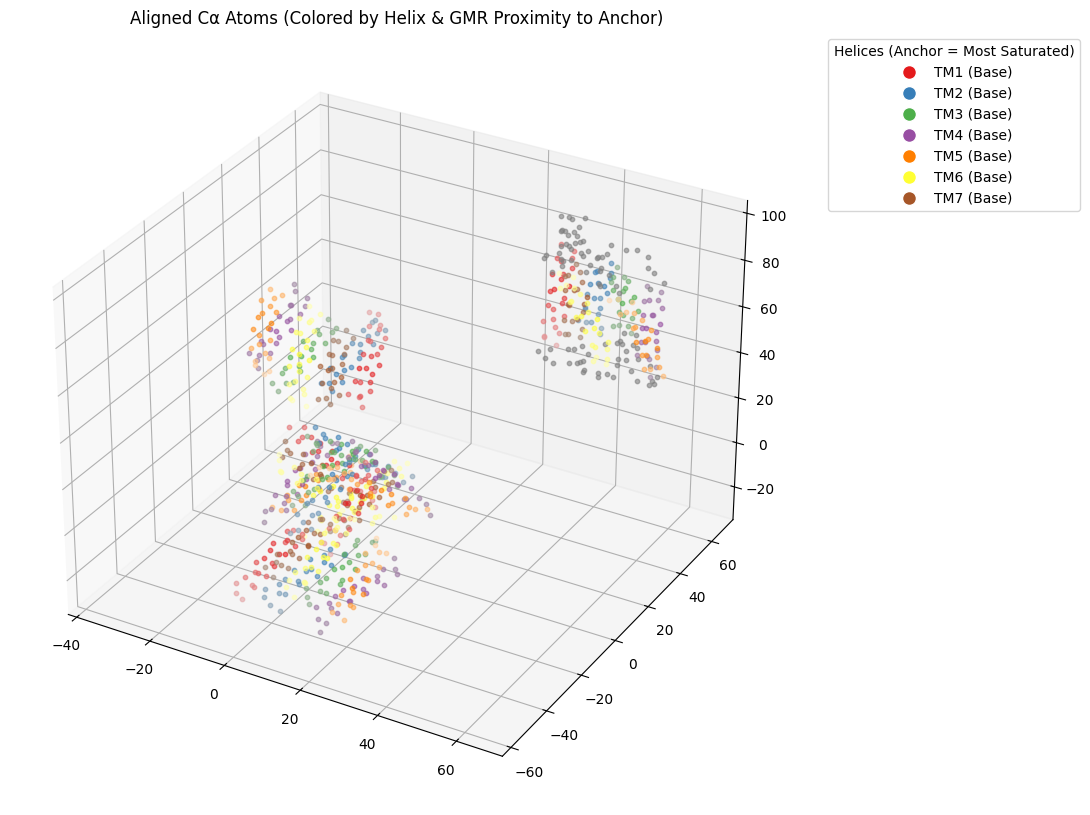

In [14]:


all_gmr_cols = msa.columns.tolist()
proteins_subset = msa_modified.index.tolist()[:5] # Plot first 5 proteins for speed, or None for all

visualize_aligned_ca_atoms_colored_by_helix(
    msa_to_visualize=msa_modified,
    data_all_structures=data['processed_structures'],
    all_msa_gmr_columns=all_gmr_cols,
    proteins_to_plot=proteins_subset, 
    dot_size=10,
    alpha_value=0.6
)

In [16]:
# todo: keep the structure alignment

In [15]:
# structure loss